# CHIMERA-Bench Demo

This notebook walks through the CHIMERA-Bench dataset: loading complexes, inspecting features, visualizing structures, and running evaluation.

In [10]:
import os
import torch
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set CHIMERA_DATA_ROOT env var or edit this path
DATA_ROOT = Path("/home/exouser/data/chimera-bench-v1.0")

print(f"Data root: {DATA_ROOT}")
print(f"Contents: {sorted([p.name for p in DATA_ROOT.iterdir()])}")

Data root: /home/exouser/data/chimera-bench-v1.0
Contents: ['.cache', 'README.md', 'complex_features', 'metadata', 'splits', 'structures']


## 1. Dataset Metadata

The metadata CSV has 2,922 complexes with 32 columns covering PDB info, species, resolution, chain assignments, and more.

In [11]:
summary = pd.read_csv(DATA_ROOT / "metadata" / "final_summary.csv")
print(f"Total complexes: {len(summary)}")
print(f"Columns: {list(summary.columns)}")
summary.head()

Total complexes: 2922
Columns: ['pdb', 'Hchain', 'Lchain', 'model', 'antigen_chain', 'antigen_type', 'antigen_het_name', 'antigen_name', 'short_header', 'date', 'compound', 'organism', 'heavy_species', 'light_species', 'antigen_species', 'authors', 'resolution', 'method', 'r_free', 'r_factor', 'scfv', 'engineered', 'heavy_subclass', 'light_subclass', 'light_ctype', 'affinity', 'delta_g', 'affinity_method', 'temperature', 'pmid', 'complex_id', 'has_skempi']


,pdb,Hchain,Lchain,model,antigen_chain,antigen_type,antigen_het_name,antigen_name,short_header,date,...,heavy_subclass,light_subclass,light_ctype,affinity,delta_g,affinity_method,temperature,pmid,complex_id,has_skempi
0,7v05,K,k,0,X,protein,NaN,circumsporozoite protein,"ANTIMICROBIAL PROTEIN,IMMUNE SYSTEM/CELL INVASION",11/23/22,...,IGHV3,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN,7v05_K_k_X,False
1,7z3a,K,P,0,C,protein,NaN,amc009 sosipv5.2 envelope glycoprotein gp120,VIRAL PROTEIN,01/08/09,...,IGHV1,IGLV2,Lambda,NaN,NaN,NaN,NaN,NaN,7z3a_K_P_C,False
2,7z3a,M,O,0,B,protein,NaN,amc009 sosip.v5.2 envelope glycoprotein gp41,VIRAL PROTEIN,01/08/09,...,IGHV4,IGLV3,Lambda,NaN,NaN,NaN,NaN,NaN,7z3a_M_O_B,False
3,7upd,C,F,0,G,protein,NaN,fusion glycoprotein f0,VIRAL PROTEIN/Immune System,03/29/23,...,IGHV10,IGKV8,Kappa,NaN,NaN,NaN,NaN,NaN,7upd_C_F_G,False
4,7u0p,D,I,0,B,protein,NaN,spike glycoprotein,VIRAL PROTEIN,01/08/09,...,IGHV5,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN,7u0p_D_I_B,False


In [12]:
# Dataset statistics
print(f"Resolution: mean={summary['resolution'].mean():.2f} A, median={summary['resolution'].median():.2f} A")
print(f"Methods: {summary['method'].value_counts().to_dict()}")
print(f"Antigen types: {summary['antigen_type'].value_counts().to_dict()}")
print(f"Heavy species: {summary['heavy_species'].value_counts().head(5).to_dict()}")
print(f"SKEMPI-linked: {summary['has_skempi'].sum()}")

Resolution: mean=2.59 A, median=2.72 A
Methods: {'X-RAY DIFFRACTION': 1929, 'ELECTRON MICROSCOPY': 989, 'ELECTRON MICROSCOPY / HOMOLOGY MODEL': 3, 'X-RAY DIFFRACTION, 1': 1}
Antigen types: {'protein': 2485, 'peptide': 437}
Heavy species: {'homo sapiens': 1824, 'mus musculus': 755, 'macaca mulatta': 76, 'oryctolagus cuniculus': 67, 'synthetic construct': 24}
SKEMPI-linked: 29


## 2. Splits

Three biologically motivated splits test generalization along different axes.

In [13]:
splits = {}
for name in ["epitope_group", "antigen_fold", "temporal"]:
    with open(DATA_ROOT / "splits" / f"{name}.json") as f:
        splits[name] = json.load(f)
    print(f"{name}: train={len(splits[name]['train'])}, val={len(splits[name]['val'])}, test={len(splits[name]['test'])}")

epitope_group: train=2338, val=292, test=292
antigen_fold: train=2338, val=292, test=292
temporal: train=2337, val=292, test=293


## 3. Loading a Complex

Each complex is a `.pt` file containing sequences, atom coordinates, annotations, numbering, and surface features.

In [14]:
# Load a test complex from the epitope_group split
cid = splits["epitope_group"]["test"][0]
feat = torch.load(DATA_ROOT / "complex_features" / f"{cid}.pt", weights_only=False)

print(f"Complex ID: {feat['complex_id']}")
print(f"Heavy chain: {len(feat['heavy_sequence'])} residues")
print(f"Light chain: {len(feat['light_sequence'])} residues")
print(f"Antigen:     {len(feat['antigen_sequence'])} residues")
print(f"\nAll keys: {feat.keys()}")

Complex ID: 7zwi_E_F_D
Heavy chain: 214 residues
Light chain: 211 residues
Antigen:     136 residues

All keys: dict_keys(['complex_id', 'heavy_sequence', 'heavy_atom14_coords', 'heavy_atom14_mask', 'heavy_ca_coords', 'light_sequence', 'light_atom14_coords', 'light_atom14_mask', 'light_ca_coords', 'antigen_sequence', 'antigen_atom14_coords', 'antigen_atom14_mask', 'antigen_ca_coords', 'epitope_residues', 'paratope_residues', 'contact_pairs', 'numbering', 'cdr_masks', 'ag_surface_points', 'ag_surface_normals', 'ag_surface_curvatures', 'ag_surface_chemical_feats', 'ag_n_surface_points', 'heavy_surface_points', 'heavy_surface_normals', 'heavy_surface_curvatures', 'heavy_surface_chemical_feats', 'heavy_n_surface_points', 'light_surface_points', 'light_surface_normals', 'light_surface_curvatures', 'light_surface_chemical_feats', 'light_n_surface_points'])


In [15]:
# Inspect shapes of coordinate arrays
for key in sorted(feat.keys()):
    val = feat[key]
    if isinstance(val, np.ndarray):
        print(f"{key:40s} ndarray  shape={str(val.shape):20s} dtype={val.dtype}")
    elif isinstance(val, str):
        print(f"{key:40s} str      len={len(val)}")
    elif isinstance(val, (list, tuple)):
        print(f"{key:40s} {type(val).__name__:8s} len={len(val)}")
    elif isinstance(val, dict):
        print(f"{key:40s} dict     keys={list(val.keys())}")
    else:
        print(f"{key:40s} {type(val).__name__:8s} = {val}")

ag_n_surface_points                      int      = 128
ag_surface_chemical_feats                ndarray  shape=(128, 6)             dtype=float32
ag_surface_curvatures                    ndarray  shape=(128, 2)             dtype=float32
ag_surface_normals                       ndarray  shape=(128, 3)             dtype=float32
ag_surface_points                        ndarray  shape=(128, 3)             dtype=float32
antigen_atom14_coords                    ndarray  shape=(136, 14, 3)         dtype=float32
antigen_atom14_mask                      ndarray  shape=(136, 14)            dtype=bool
antigen_ca_coords                        ndarray  shape=(136, 3)             dtype=float32
antigen_sequence                         str      len=136
cdr_masks                                dict     keys=['imgt', 'chothia']
complex_id                               str      len=10
contact_pairs                            list     len=72
epitope_residues                         list     len=25
heavy_

## 4. Sequences and Numbering

In [16]:
# Heavy chain sequence
print("Heavy chain sequence:")
print(feat['heavy_sequence'])

# IMGT numbering
imgt_h = feat['numbering']['imgt']['heavy']
print(f"\nIMGT numbering (first 10 residues): {imgt_h[:10]}")

# CDR masks: -1=framework, 0=CDR1, 1=CDR2, 2=CDR3
cdr_h = feat['cdr_masks']['imgt']['heavy']
for cdr_idx, cdr_name in enumerate(['CDR-H1', 'CDR-H2', 'CDR-H3']):
    positions = [i for i, x in enumerate(cdr_h) if x == cdr_idx]
    if positions:
        seq = ''.join(feat['heavy_sequence'][p] for p in positions)
        print(f"{cdr_name}: positions {positions[0]}-{positions[-1]}, sequence = {seq}")

Heavy chain sequence:
DVKLVESGGGLVKLGGSLKLSCAASGFTFSSYYMSWVRQTPEKRLELVAAINNNGGSTYYPDTVKGRFTISRDNAKNTLNLQMNSLKSEDTALYYCTRQHYGNLYFFDYWGQGTTLTVSSAKTTPPSVYPLAPNSMVTLGCLVKGYFPEPVTVTWNSGSLSSGVHTFPAVLESDLYTLSSSVTVPSSPWPSETVTCNVAHPASSTKVDKKIVPR

IMGT numbering (first 10 residues): [(1, ' ', 'D'), (2, ' ', 'V'), (3, ' ', 'K'), (4, ' ', 'L'), (5, ' ', 'V'), (6, ' ', 'E'), (7, ' ', 'S'), (8, ' ', 'G'), (9, ' ', 'G'), (11, ' ', 'G')]
CDR-H1: positions 25-32, sequence = GFTFSSYY
CDR-H2: positions 50-57, sequence = INNNGGST
CDR-H3: positions 96-108, sequence = TRQHYGNLYFFDY


In [17]:
# Same for light chain CDRs (mask values: 3=CDR-L1, 4=CDR-L2, 5=CDR-L3)
cdr_l = feat['cdr_masks']['imgt']['light']
for cdr_idx, cdr_name in zip([3, 4, 5], ['CDR-L1', 'CDR-L2', 'CDR-L3']):
    positions = [i for i, x in enumerate(cdr_l) if x == cdr_idx]
    if positions:
        seq = ''.join(feat['light_sequence'][p] for p in positions)
        print(f"{cdr_name}: positions {positions[0]}-{positions[-1]}, sequence = {seq}")

CDR-L1: positions 26-30, sequence = SSVTY
CDR-L2: positions 48-50, sequence = ATS
CDR-L3: positions 87-95, sequence = QQWSSNPLT


## 5. Epitope and Paratope

In [18]:
print(f"Epitope residues ({len(feat['epitope_residues'])}):")
for chain, resid, resname in feat['epitope_residues'][:10]:
    print(f"  Chain {chain}, Res {resid}, {resname}")
if len(feat['epitope_residues']) > 10:
    print(f"  ... and {len(feat['epitope_residues']) - 10} more")

print(f"\nParatope residues ({len(feat['paratope_residues'])}):")
for chain, resid, resname in feat['paratope_residues'][:10]:
    print(f"  Chain {chain}, Res {resid}, {resname}")

print(f"\nContact pairs ({len(feat['contact_pairs'])}):")
for cp in feat['contact_pairs'][:5]:
    ab_chain, ab_resid, ab_resname, ag_chain, ag_resid, ag_resname, dist = cp
    print(f"  Ab {ab_chain}:{ab_resname}{ab_resid} -- Ag {ag_chain}:{ag_resname}{ag_resid}  ({dist:.2f} A)")

Epitope residues (25):
  Chain D, Res 322, SER
  Chain D, Res 323, ALA
  Chain D, Res 324, HIS
  Chain D, Res 347, ASP
  Chain D, Res 349, ILE
  Chain D, Res 357, TYR
  Chain D, Res 358, GLN
  Chain D, Res 359, PRO
  Chain D, Res 360, GLU
  Chain D, Res 361, SER
  ... and 15 more

Paratope residues (31):
  Chain E, Res 2, VAL
  Chain E, Res 37, TYR
  Chain E, Res 38, TYR
  Chain E, Res 55, ALA
  Chain E, Res 56, ILE
  Chain E, Res 57, ASN
  Chain E, Res 58, ASN
  Chain E, Res 64, SER
  Chain E, Res 65, THR
  Chain E, Res 66, TYR

Contact pairs (72):
  Ab E:VAL2 -- Ag D:SER322  (4.00 A)
  Ab E:TYR37 -- Ag D:SER322  (3.17 A)
  Ab E:TYR37 -- Ag D:ALA323  (3.82 A)
  Ab E:TYR37 -- Ag D:HIS324  (2.63 A)
  Ab E:TYR38 -- Ag D:GLU360  (2.69 A)


## 6. 3D Structure Visualization

Plot the CA coordinates of a complex, colored by chain, with epitope and paratope residues highlighted.

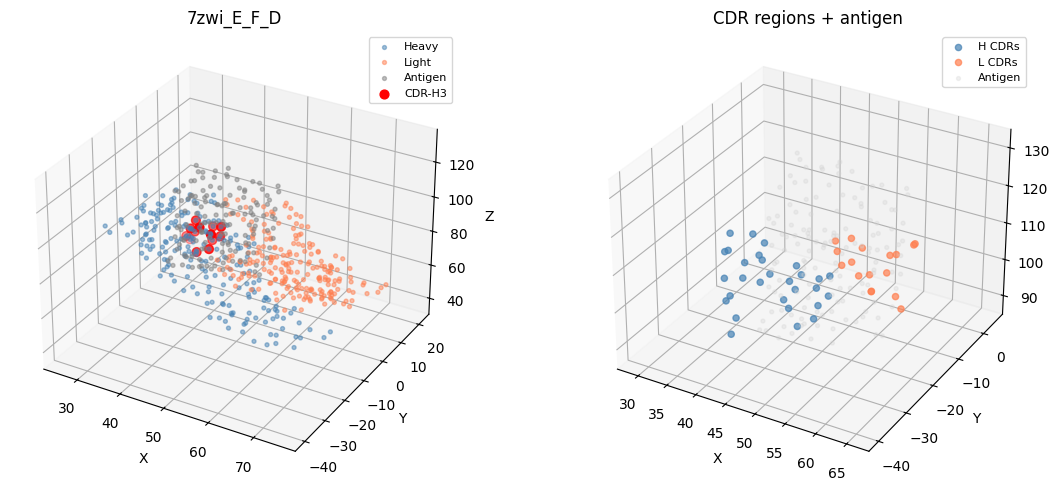

In [19]:
fig = plt.figure(figsize=(12, 5))

# --- Left panel: full complex ---
ax1 = fig.add_subplot(121, projection='3d')
h_ca = feat['heavy_ca_coords']
l_ca = feat['light_ca_coords']
a_ca = feat['antigen_ca_coords']

ax1.scatter(*h_ca.T, s=8, alpha=0.5, label='Heavy', c='steelblue')
ax1.scatter(*l_ca.T, s=8, alpha=0.5, label='Light', c='coral')
ax1.scatter(*a_ca.T, s=8, alpha=0.5, label='Antigen', c='gray')

# Highlight CDR-H3
cdr_h3_pos = [i for i, x in enumerate(feat['cdr_masks']['imgt']['heavy']) if x == 2]
if cdr_h3_pos:
    h3_ca = h_ca[cdr_h3_pos]
    ax1.scatter(*h3_ca.T, s=40, c='red', marker='o', label='CDR-H3', zorder=5)

ax1.set_title(f"{feat['complex_id']}")
ax1.legend(fontsize=8)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# --- Right panel: interface zoom ---
ax2 = fig.add_subplot(122, projection='3d')

# Get epitope CA coords
epi_indices = []
for chain, resid, resname in feat['epitope_residues']:
    # Find index in antigen sequence (approximate by position)
    epi_indices.append(resid if isinstance(resid, int) else int(resid))

# Plot paratope and epitope
para_h = [i for i, x in enumerate(feat['cdr_masks']['imgt']['heavy']) if x >= 0]
para_l = [i for i, x in enumerate(feat['cdr_masks']['imgt']['light']) if x >= 0]

if para_h:
    ax2.scatter(*h_ca[para_h].T, s=20, c='steelblue', alpha=0.7, label='H CDRs')
if para_l:
    ax2.scatter(*l_ca[para_l].T, s=20, c='coral', alpha=0.7, label='L CDRs')
ax2.scatter(*a_ca.T, s=8, c='lightgray', alpha=0.3, label='Antigen')

ax2.set_title('CDR regions + antigen')
ax2.legend(fontsize=8)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

## 7. Surface Features

Antigen surface points: (128, 3)
Antigen surface normals: (128, 3)
Antigen surface curvatures: (128, 2) (mean, Gaussian)
Antigen surface chemical feats: (128, 6)
  (hydropathy, charge, H-bond donor, H-bond acceptor, aromaticity, polarity)


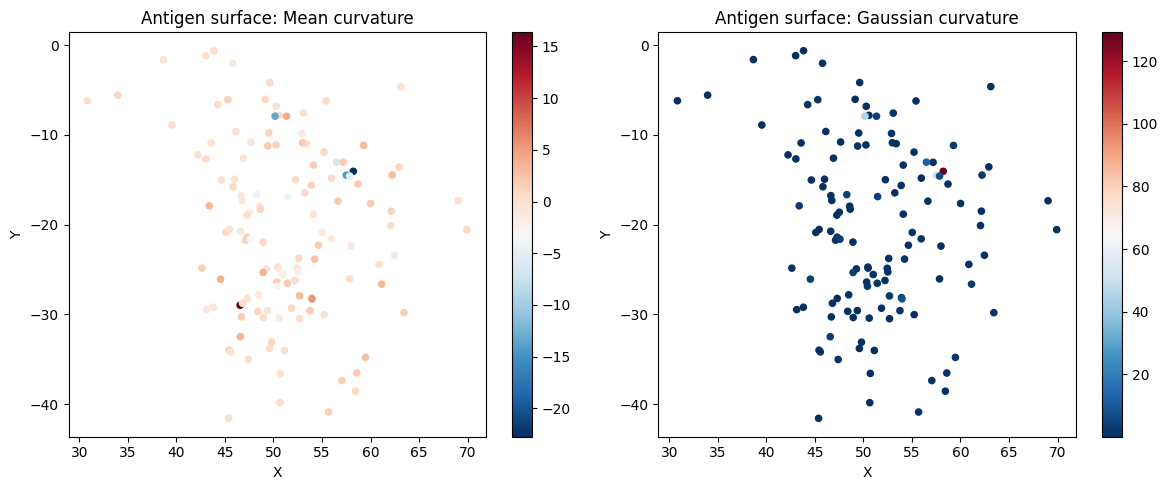

In [20]:
print(f"Antigen surface points: {feat['ag_surface_points'].shape}")
print(f"Antigen surface normals: {feat['ag_surface_normals'].shape}")
print(f"Antigen surface curvatures: {feat['ag_surface_curvatures'].shape} (mean, Gaussian)")
print(f"Antigen surface chemical feats: {feat['ag_surface_chemical_feats'].shape}")
print(f"  (hydropathy, charge, H-bond donor, H-bond acceptor, aromaticity, polarity)")

# Visualize curvature on surface
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pts = feat['ag_surface_points']
curv = feat['ag_surface_curvatures']

for i, (ax, name) in enumerate(zip(axes, ['Mean curvature', 'Gaussian curvature'])):
    sc = ax.scatter(pts[:, 0], pts[:, 1], c=curv[:, i], cmap='RdBu_r', s=20)
    ax.set_title(f'Antigen surface: {name}')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

## 8. Working with PDB Structures

In [21]:
# PDB files are included for direct structural analysis
pdb_dir = DATA_ROOT / "structures"
pdb_files = list(pdb_dir.glob("*.pdb"))
print(f"PDB structures available: {len(pdb_files)}")
print(f"Example: {pdb_files[0].name}")

# Read a PDB file
with open(pdb_files[0]) as f:
    lines = f.readlines()
print(f"Lines in PDB: {len(lines)}")
print(f"First ATOM line: {next(l for l in lines if l.startswith('ATOM')).strip()}")

PDB structures available: 2721
Example: 7rr0.pdb
Lines in PDB: 3301
First ATOM line: ATOM      1  N   ASN A 334      90.451 104.992  50.123  1.00114.02           N
